# Dependencies

In [88]:
import json
import pandas as pd
pd.set_option('display.max_rows', None)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error,mean_absolute_percentage_error, mean_squared_error,root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import wandb
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge,Lasso
import joblib


# Class Based Pipeline


In [ ]:
class coloumbtransform:
    # Initialize parameters for the class, matching the logic from the previous script
    def __init__(self,n_components):
        self.n_components=n_components
        self.scaler=StandardScaler()
        self.pca= None
        self.max_atoms=0
    
    # This method encapsulates the JSON loading and flattening logic seen earlier
    def coloumbmatrix(self,jsonpath):
        import joblib
        self.jsonpath=jsonpath
        data=[]
        for path in jsonpath:
            with open(path,'r') as f:
                datas =json.load(f)
                data.append(datas)
                if max(len(m['atoms']) for m in datas) > self.max_atoms:
                    self.max_atoms= max(len(m['atoms']) for m in datas)
                    
        all_molecules= []
        # Replicates the loop used to extract atom types and xyz coordinates from the JSON objects
        for dataset in data:
            for molecules in dataset:
                row_data=  {'energy':molecules['En'],
                            'n_atoms':len(molecules['atoms'])}
                for i in range(self.max_atoms):
                    if i<len(molecules['atoms']):
                        atom =molecules['atoms'][i]
                        row_data[f'atom_{i}_type']= atom['type']
                        row_data[f'atom_{i}_x']= atom['xyz'][0]
                        row_data[f'atom_{i}_y']= atom['xyz'][1]
                        row_data[f'atom_{i}_z']= atom['xyz'][2]
                    else:
                        # Maintains the same padding logic for smaller molecules
                        row_data[f'atom_{i}_type']= None
                        row_data[f'atom_{i}_x']= None
                        row_data[f'atom_{i}_y']= None
                        row_data[f'atom_{i}_z']= None
                    
                all_molecules.append(row_data)

        df=pd.DataFrame(all_molecules)
        n_atoms = df["n_atoms"].to_numpy()
        df = df.drop(columns=["n_atoms"])
    
        # The same atomic number mapping used in the earlier cell
        zmap = {
            'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10,
            'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15, 'S': 16, 'Cl': 17, 'Ar': 18,
            'K': 19, 'Ca': 20, 'Sc': 21, 'Ti': 22, 'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26,
            'Co': 27, 'Ni': 28, 'Cu': 29, 'Zn': 30, 'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34,
            'Br': 35, 'Kr': 36, 'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41, 'Mo': 42,
            'Tc': 43, 'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50,
            'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54,
            'Cs': 55, 'Ba': 56, 'La': 57, 'Ce': 58, 'Pr': 59, 'Nd': 60,
            'Pm': 61, 'Sm': 62, 'Eu': 63, 'Gd': 64, 'Tb': 65, 'Dy': 66,
            'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71,
            'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77,
            'Pt': 78, 'Au': 79, 'Hg': 80, 'Tl': 81, 'Pb': 82, 'Bi': 83,
            'Po': 84, 'At': 85, 'Rn': 86,
            'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90, 'Pa': 91, 'U': 92,
            'Np': 93, 'Pu': 94, 'Am': 95, 'Cm': 96, 'Bk': 97, 'Cf': 98,
            'Es': 99, 'Fm': 100
        }

        # Processes atom types into numerical Z-values as done previously
        typecols=[col for col in df.columns if col.endswith('_type')]
        df[typecols]=df[typecols].replace(zmap)
        df[typecols]=df[typecols].fillna(0)
        
        # Identifies and isolates coordinate indices for 3D reshaping
        indices=[i for start in range(2,self.max_atoms*4,4) for i in range(start,start+3)]
        print(df.shape)
        dfnew=df.iloc[:,indices]
        print(dfnew.shape)

        d3coords=dfnew.to_numpy(dtype=np.float32)
        d3coords=d3coords.reshape(-1,self.max_atoms,3)

        # Uses the same einsum operations for the Gram matrix and distance calculations
        grammatrix= np.einsum('ijk,ilk->ijl',d3coords,d3coords)
        norms=np.einsum('ijj->ij',grammatrix)
        dist_sq=norms[:,:,None].astype(np.float32) +norms[:,None,:].astype(np.float32) -2*grammatrix.astype(np.float32)

        dist_sq= np.sqrt(np.maximum(dist_sq,0))
        
        # Extracts Z-values matrix for the Coulomb calculation numerator
        indices=[i for i in range(1,((self.max_atoms*4)-1),4)]
        zvalsmatrix=df.iloc[:,indices]
        zvalsmatrix=zvalsmatrix.to_numpy(dtype=np.float32)

        # Computes Zi * Zj for the matrix elements
        all_zvals=np.einsum('ij,ik->ijk',zvalsmatrix,zvalsmatrix)

        # Constructs the Coulomb Matrix elements (Zi * Zj / Rij)
        columbmatrix= all_zvals/dist_sq

        # Replicates the diagonal calculation: 0.5 * Zi^2.4
        diags=0.5*(zvalsmatrix**2.4)

        # Manually updates diagonals for every molecule in the set
        val= np.arange(self.max_atoms)
        for k in range(df.shape[0]):
            for i in range(self.max_atoms):
                columbmatrix[k,i,i]=diags[k,i]
        
        # Flattens the matrix and separates the target 'energy' (y)
        x=columbmatrix.reshape(df.shape[0],-1)
        y=df.iloc[:,0]

        x=pd.DataFrame(x.astype(np.float32))
        x=x.fillna(0)

        from sklearn.decomposition import IncrementalPCA
        # Initialize the StandardScaler to give all features a mean of 0 and variance of 1
        sc=StandardScaler()
        # Fit and transform the data 
        x_scaled=sc.fit_transform(x).astype(np.float32)
        del x
        # Initialize PCA to retain enough components to explain 95% of the total variance
        pca=IncrementalPCA(self.n_components,batch_size=1400)

        for start in range(0,x_scaled.shape[0],1400):
            end=min(x_scaled.shape[0],start+1400)
            pca.partial_fit(x_scaled[start:end])
        
        x_pca=np.zeros((x_scaled.shape[0],self.n_components),dtype=np.float32)

        for start in range(0,x_scaled.shape[0],1400):
            end=min(start+1400,x_scaled.shape[0])
            x_pca[start:end]=pca.transform(x_scaled[start:end]).astype(np.float32)
            if start %10000:
                print(f'almost done with {start} runs')
    
        # # Transform the scaled features into the reduced PCA space
        
 

        import joblib

        pipeline_bundle = {
            "scaler": sc,
            "pca": pca,
            "max_atoms": self.max_atoms,
            "n_atoms": n_atoms
        }

        joblib.dump(pipeline_bundle, "coloumb_pca_pipeline1400.joblib")

        joblib.dump((x_pca, y), "train_data_pca1400.joblib")
       
        return x_pca,y

In [ ]:
Training_set=coloumbtransform(n_components=1400)
x_train,y_train=Training_set.coloumbmatrix(jsonpath = [
    r"Dataset/pubChem_p_00000001_00025000.json",
    r"Dataset/pubChem_p_00025001_00050000.json",
    r"Dataset/pubChem_p_00050001_00075000.json",
    r"Dataset/pubChem_p_00075001_00100000.json",
    r"Dataset/pubChem_p_00100001_00125000.json",
    r"Dataset/pubChem_p_00125001_00150000.json",
    r"Dataset/pubChem_p_00150001_00175000.json",
    r"Dataset/pubChem_p_00175001_00200000.json",
    r"Dataset/pubChem_p_00200001_00225000.json",
    r"Dataset/pubChem_p_00225001_00250000.json",
])

(171137, 485)
(171137, 363)
almost done with 1400 runs
almost done with 2800 runs
almost done with 4200 runs
almost done with 5600 runs
almost done with 7000 runs
almost done with 8400 runs
almost done with 9800 runs
almost done with 11200 runs
almost done with 12600 runs
almost done with 14000 runs
almost done with 15400 runs
almost done with 16800 runs
almost done with 18200 runs
almost done with 19600 runs
almost done with 21000 runs
almost done with 22400 runs
almost done with 23800 runs
almost done with 25200 runs
almost done with 26600 runs
almost done with 28000 runs
almost done with 29400 runs
almost done with 30800 runs
almost done with 32200 runs
almost done with 33600 runs
almost done with 35000 runs
almost done with 36400 runs
almost done with 37800 runs
almost done with 39200 runs
almost done with 40600 runs
almost done with 42000 runs
almost done with 43400 runs
almost done with 44800 runs
almost done with 46200 runs
almost done with 47600 runs
almost done with 49000 runs

# Summary Statistics for Training Data 


      Standard Deviation of Energies: 35.2404451983538
      Mean of Energies: 50.33464262023992
      Minimum Energy -99.0292
      Maximum Energy 465.4899

      Total number of Molecules: 171137
      Total number of atoms: 6147944
      Mean number of atoms : 35.924107586319735
      Standard deviation of atoms: 14.948319811899392







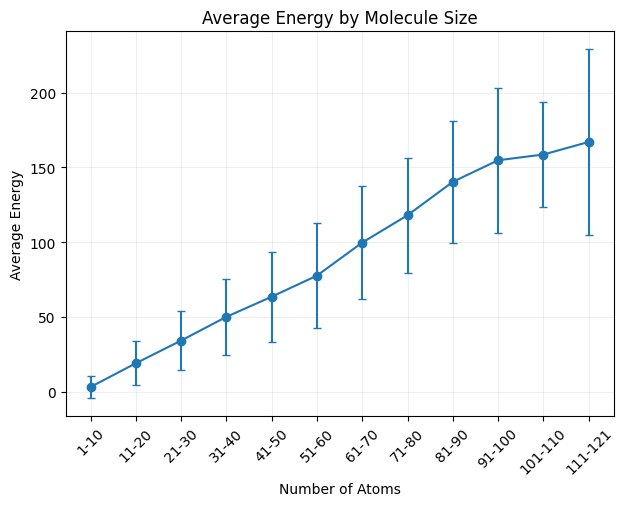

In [ ]:
x,y=joblib.load("train_data_pca.joblib")
original_set = joblib.load("coloumb_pca_pipeline.joblib")
n_atoms=original_set['n_atoms']
print(f'''
      Standard Deviation of Energies: {np.std(y)}
      Mean of Energies: {np.mean(y)}
      Minimum Energy {np.min(y)}
      Maximum Energy {np.max(y)}
    
      Total number of Molecules: {y.shape[0]}
      Total number of atoms: {n_atoms.sum()}
      Mean number of atoms : {n_atoms.mean()}
      Standard deviation of atoms: {n_atoms.std()}



''')
atoms_list=[]
y_list=[]
y_mean=[]
y_std=[]
atom_range=[]

for k in range(1,13):
      atom_count=[n_atoms[i] for i in range(len(n_atoms)) if (n_atoms[i]>=1+(10*(k-1)) and n_atoms[i]<10*k+1) or (k==12 and n_atoms[i]==121)]
      ylist=[y.iloc[i] for i in range(len(n_atoms)) if (n_atoms[i]>=1+(10*(k-1)) and n_atoms[i]<10*k+1) or (k==12 and n_atoms[i]==121)]

      atoms_list.append(atom_count)
      y_list.append(ylist)

      y_mean.append(np.mean(ylist))
      y_std.append(np.std(ylist))
      atom_range.append(f'{1+(10*(k-1))}-{10*k if k<12 else 121}')

plt.figure()
plt.errorbar(atom_range,y_mean,yerr=y_std,marker='o',capsize=3)
plt.xlabel('Number of Atoms')
plt.ylabel('Average Energy')
plt.title('Average Energy by Molecule Size')
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()

# Atomic Distribution

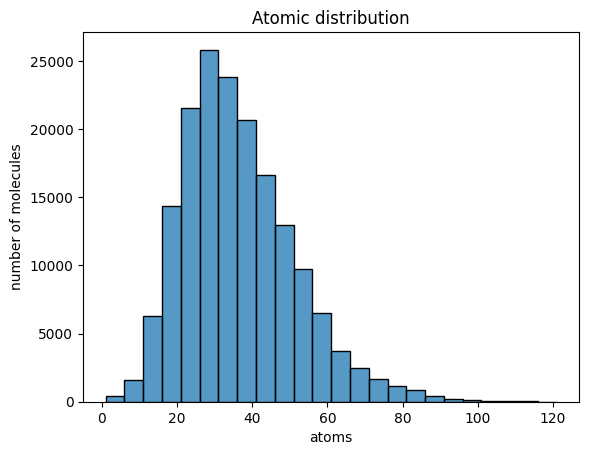

In [87]:
pipeline = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms = pipeline["n_atoms"]
n_atoms=n_atoms

plt.figure()
sns.histplot(n_atoms,binwidth=5)
plt.xlabel('atoms')
plt.ylabel('number of molecules')
plt.title('Atomic distribution')
plt.show()



# Cumulative Variance Plot

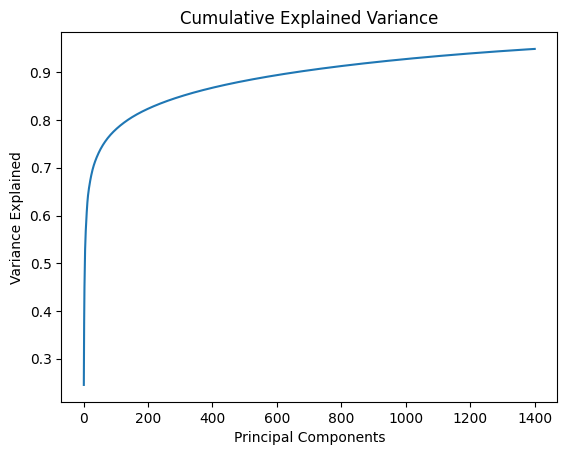

Variance retained :0.949%


In [73]:
pipeline = joblib.load("coloumb_pca_pipeline1400.joblib")
pca = pipeline["pca"]

pca_values= np.cumsum(pca.explained_variance_ratio_)
plt.figure()
plt.plot(list(range(1,1401)),pca_values)
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Cumulative Explained Variance')
plt.show()

n_atoms=pipeline['n_atoms']
print(f'Variance retained :{pca.explained_variance_ratio_.sum():.3f}%')


## Defining Error Metrics and Plotting Function

In [89]:
def Metrics(predicted,actual,model):
    # Print header for the specific model being evaluated
    print(f'Following are Statistics for {model}')
    print('')

    # Initialize a figure for the Kernel Density Estimate (KDE) of residuals
    plt.figure()
    plt.title('Residual Distribution')
    plt.xlabel('Predicted - Actual')
    # Plot the distribution of errors (should be centred at 0 optimally)
    sns.kdeplot(predicted-actual,cut=0)
    # Set x-axis limits to focus on the common error range
    plt.xlim(-200,200)
    plt.grid(alpha=0.2) # Gridlines
    plt.show()

    # Initialize a figure for the scatter plot comparing predictions to ground truth
    plt.figure()
    # Use very small points (s=0.1) due to the large dataset size (18,205 samples)
    plt.scatter(predicted,actual,s=0.1)
    # Draw a 45-degree reference line representing perfect prediction
    plt.axline((0,0),slope=1,linestyle='--',label='True fit',color='red')
    plt.title('predicted vs actual')
    # Set limits based on the energy range (-74 to 248)
    plt.xlim(-75,300)
    plt.ylim(-75,300)
    plt.xlabel('predicted')
    plt.ylabel('Actual')
    plt.grid(alpha=0.2)
    plt.show()

    # Calculate standard regression performance metrics
    r2=r2_score(actual,predicted)
    mse=mean_squared_error(predicted,actual)
    mae= mean_absolute_error(predicted,actual)
    rmse=root_mean_squared_error(predicted,actual)
    mpe= mean_absolute_percentage_error(predicted,actual)

    # Return a formatted string containing the calculated statistical results
    return print(f'''
                 Mean Square Error is : {mse}
                 Mean Absolute Error is : {mae}
                 R2 score is : {r2}
                 Root Mean Square error is: {rmse}
                 Mean percentage error is: {mpe}''')

# MLP (Second Best Found Model)

Iteration 1, loss = 253.79481997
Iteration 2, loss = 139.85114646
Iteration 3, loss = 110.44600024
Iteration 4, loss = 89.67963354
Iteration 5, loss = 76.00517428
Iteration 6, loss = 65.73415532
Iteration 7, loss = 58.22979106
Iteration 8, loss = 51.95050900
Iteration 9, loss = 47.28804128
Iteration 10, loss = 43.25672056
Iteration 11, loss = 40.51349348
Iteration 12, loss = 37.55574015
Iteration 13, loss = 34.88236173
Iteration 14, loss = 32.72677416
Iteration 15, loss = 30.70565205
Iteration 16, loss = 28.56199431
Iteration 17, loss = 27.52229009
Iteration 18, loss = 25.84316793
Iteration 19, loss = 24.32858900
Iteration 20, loss = 23.65310082
Iteration 21, loss = 22.46012169
Iteration 22, loss = 21.32716626
Iteration 23, loss = 19.79841308
Iteration 24, loss = 19.01657188
Iteration 25, loss = 21.73276355
Iteration 26, loss = 17.61673289
Iteration 27, loss = 18.63995235
Iteration 28, loss = 16.69900338
Iteration 29, loss = 15.37971942
Iteration 30, loss = 14.67765270
Iteration 31, lo

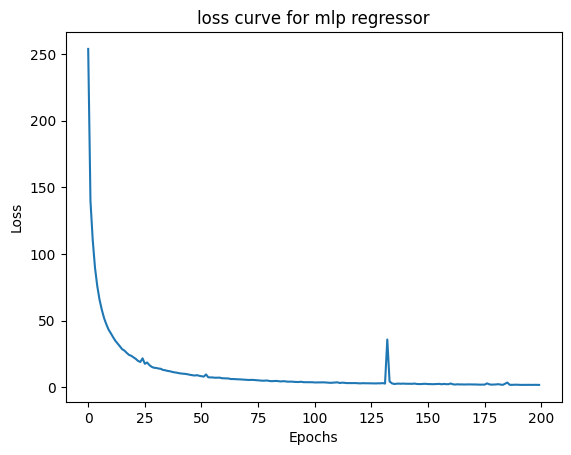

Following are Statistics for MLPRegressor



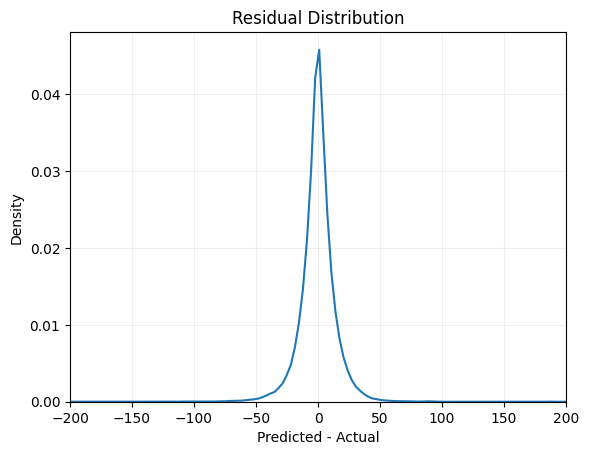

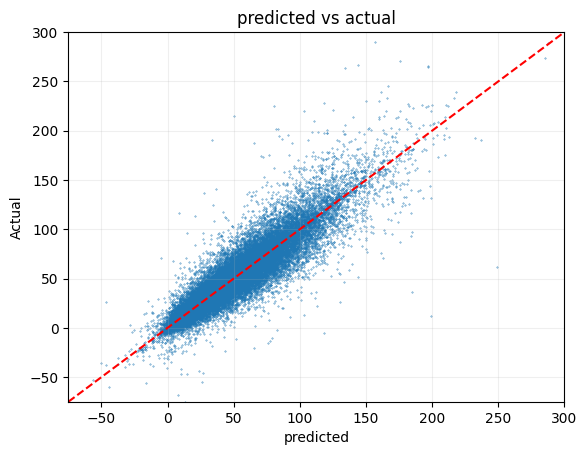


                 Mean Square Error is : 212.68761120095067
                 Mean Absolute Error is : 9.567706350408773
                 R2 score is : 0.8308958675219353
                 Root Mean Square error is: 14.583813328514276
                 Mean percentage error is: 0.43840260551716


In [ ]:
# Split the PCA-reduced features into training (80%) and testing (20%) sets
x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']
x_train,x_test,y_train,y_test,n_atoms_train,n_atoms_test=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)
# Initialize the Multi-Layer Perceptron with two hidden layers of 10 neurons each
mlp=MLPRegressor(hidden_layer_sizes=(512,256,128,64,64,28,64,16), learning_rate_init=0.0008,verbose=1)
# Train the model on the training data
mlp.fit(x_train,y_train)
# Generate predictions for the held-out test set
predicted=mlp.predict(x_test)

# Initialize a figure to visualize the training progress
plt.figure()
# Plot the loss value calculated at each iteration (epoch)
plt.plot(mlp.loss_curve_)
plt.title('loss curve for mlp regressor')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Execute the custom Metrics function to generate residual plots and statistical scores
Metrics(predicted,y_test,'MLPRegressor')
joblib.dump(mlp,'mlp512_256_128_64_64_28_64_16')

# Best Found Model (MLP)

Iteration 1, loss = 269.94129474
Iteration 2, loss = 132.88743516
Iteration 3, loss = 107.42179678
Iteration 4, loss = 87.52022106
Iteration 5, loss = 72.29833080
Iteration 6, loss = 59.97774728
Iteration 7, loss = 51.98399863
Iteration 8, loss = 45.31982947
Iteration 9, loss = 40.62072701
Iteration 10, loss = 35.64277047
Iteration 11, loss = 32.70158941
Iteration 12, loss = 29.29876908
Iteration 13, loss = 28.13534696
Iteration 14, loss = 25.74737614
Iteration 15, loss = 23.97787579
Iteration 16, loss = 22.11069566
Iteration 17, loss = 20.50094854
Iteration 18, loss = 19.95496325
Iteration 19, loss = 18.33150471
Iteration 20, loss = 17.59323133
Iteration 21, loss = 16.78691246
Iteration 22, loss = 16.07543664
Iteration 23, loss = 14.90958323
Iteration 24, loss = 14.30850317
Iteration 25, loss = 13.65421999
Iteration 26, loss = 13.15293780
Iteration 27, loss = 12.64135691
Iteration 28, loss = 12.28168095
Iteration 29, loss = 11.87908244
Iteration 30, loss = 11.17400063
Iteration 31, lo

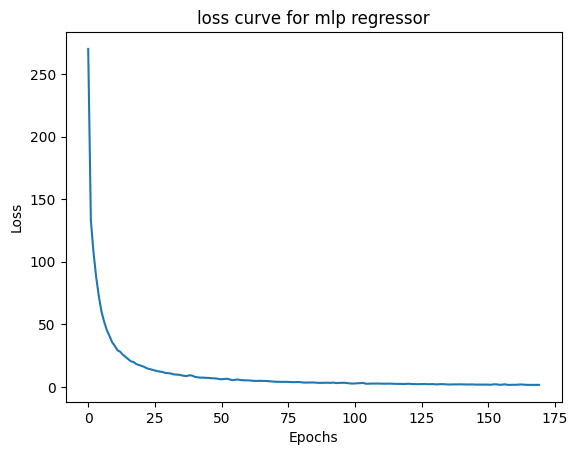

Following are Statistics for MLPRegressor



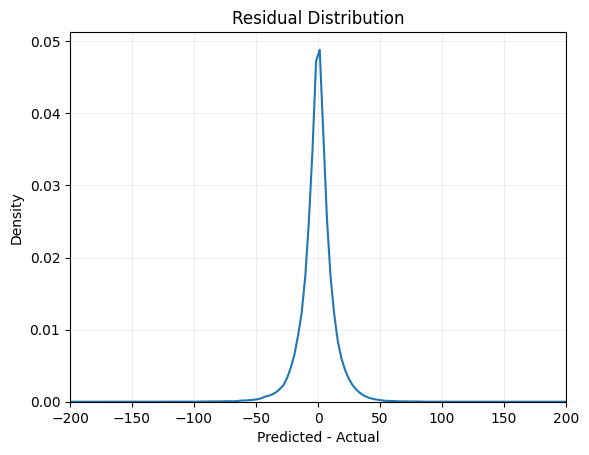

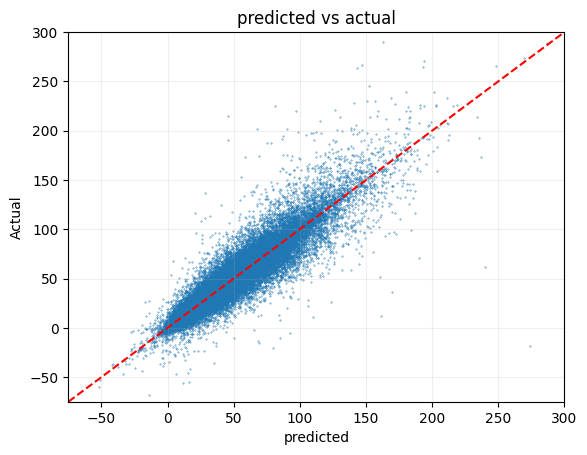


                 Mean Square Error is : 193.1010679510561
                 Mean Absolute Error is : 9.013500897463631
                 R2 score is : 0.846468779295288
                 Root Mean Square error is: 13.896081028515058
                 Mean percentage error is: 0.48408568193144763


['mlp1024_512_256_128_64_64_28_64_16']

In [ ]:
# Split the PCA-reduced features into training (80%) and testing (20%) sets
x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']
x_train,x_test,y_train,y_test,n_atoms_train,n_atoms_test=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)

mlp1024=MLPRegressor(hidden_layer_sizes=(1024,512,256,128,64,64,28,64,16), learning_rate_init=0.00025,verbose=1)
# Train the model on the training data
mlp1024.fit(x_train,y_train)
# Generate predictions for the held-out test set
predicted=mlp1024.predict(x_test)

# Initialize a figure to visualize the training progress
plt.figure()
# Plot the loss value calculated at each iteration (epoch)
plt.plot(mlp1024.loss_curve_)
plt.title('loss curve for mlp regressor')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Execute the custom Metrics function to generate residual plots and statistical scores
Metrics(predicted,y_test,'MLPRegressor')
joblib.dump(mlp1024,'mlp1024_512_256_128_64_64_28_64_16')

In [ ]:
x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']
x_trains,x_tests,y_trains,y_tests,n_atoms_trains,n_atoms_tests=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)

a=mlp1024.predict(x_tests)
print(r2_score(y_tests,a))

0.846468779295288


# HistGradboost (Third Best Model)

Following are Statistics for hgr Regressor



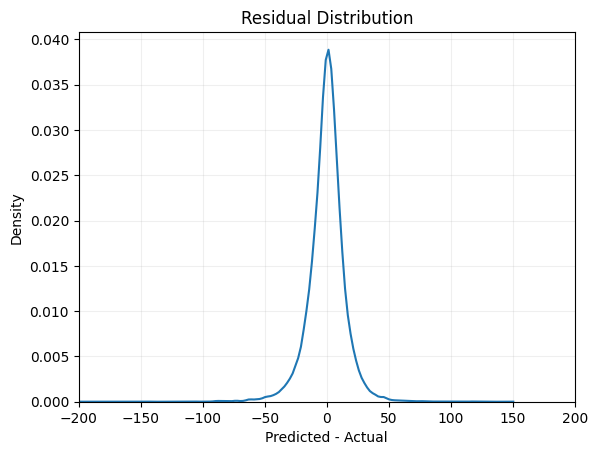

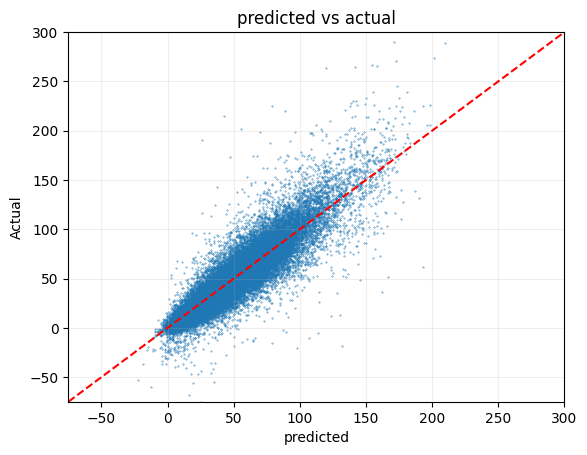


                 Mean Square Error is : 234.87602039089217
                 Mean Absolute Error is : 10.398168199291435
                 R2 score is : 0.8132542584693598
                 Root Mean Square error is: 15.325665414294159
                 Mean percentage error is: 0.4101048049881646


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']
x_train,x_test,y_train,y_test,n_atoms_train,n_atoms_test=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)
hgr_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.02,
    max_iter=1200,
    max_leaf_nodes=150,
    l2_regularization=0.05,
    random_state=10
)

hgr_model.fit(x_train,y_train)
predicted=hgr_model.predict(x_test)


Metrics(predicted,y_test,'hgr Regressor')

# Ridge LR (for comparison)

Following are Statistics for Ridge



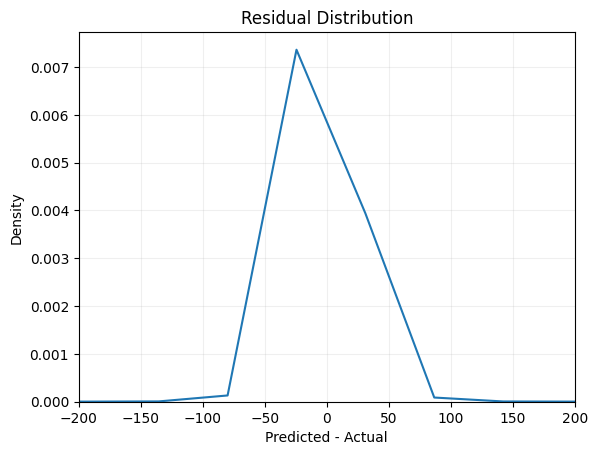

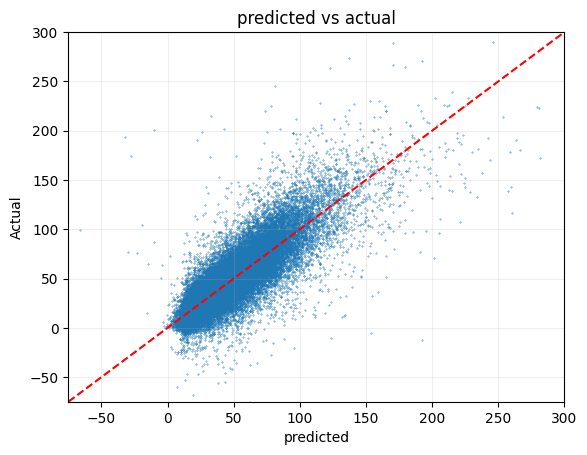


                 Mean Square Error is : 2933.561948923806
                 Mean Absolute Error is : 14.329545616609343
                 R2 score is : -1.3324228695893279
                 Root Mean Square error is: 54.16236653732743
                 Mean percentage error is: 0.35719081512020223


In [ ]:
x,y=joblib.load("train_data_pca1400.joblib")
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)
ridge=Ridge(alpha=0.3)
ridge.fit(x_train,y_train)
predicted=ridge.predict(x_test)
Metrics(predicted,y_test,'Ridge')

# Follows from the comments of the MLP cell

# Lasso LR (for comparison)

Following are Statistics for Lasso



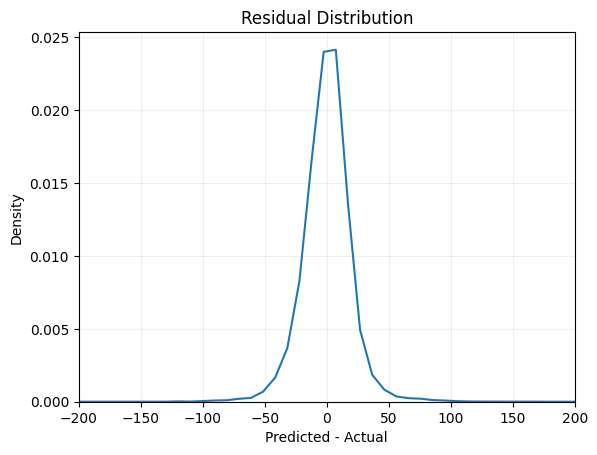

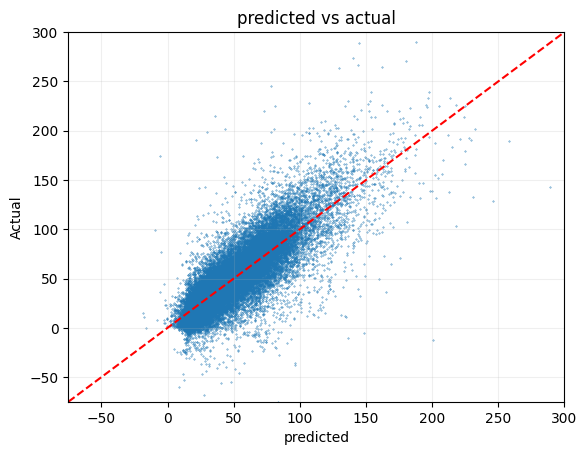


                 Mean Square Error is : 458.6717466532894
                 Mean Absolute Error is : 14.089904332845585
                 R2 score is : 0.635318261500807
                 Root Mean Square error is: 21.41662313842426
                 Mean percentage error is: 0.35396062965345687


In [ ]:
x,y=joblib.load("train_data_pca1400.joblib")
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)
lasso=Lasso(alpha=0.3)
lasso.fit(x_train,y_train)
predicted=lasso.predict(x_test)
Metrics(predicted,y_test,'Lasso')

# Follows from the comments of the MLP cell

# Redacted Models


In [ ]:
# x,y=joblib.load("train_data_pca1400.joblib")
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)
# gradboost=GradientBoostingRegressor(n_estimators=100)
# gradboost.fit(x_train,y_train)
# predicted=gradboost.predict(x_test)

# plt.plot(range(1, 101), gradboost.train_score_)
# plt.title('Loss Curve for Gradient Boosting')
# plt.xlabel('Iterations')
# plt.ylabel('Loss')
# plt.show()
# Metrics(predicted,y_test,'Gradient Boosting')

# # Follows from the comments of the MLP cell

In [ ]:
# x,y=joblib.load("train_data_pca1400.joblib")
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)
# rf_model=RandomForestRegressor(n_estimators=250, n_jobs=-1)
# rf_model.fit(x_train,y_train)
# predicted=rf_model.predict(x_test)
# Metrics(predicted,y_test,'RandomForest Regressor')

# # Follows from the comments of the MLP cell

## HistGradientBoosting (With different hyperparameters)

Following are Statistics for hgr Regressor



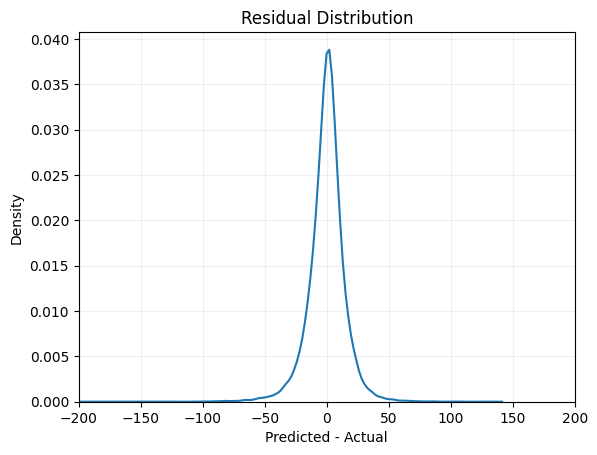

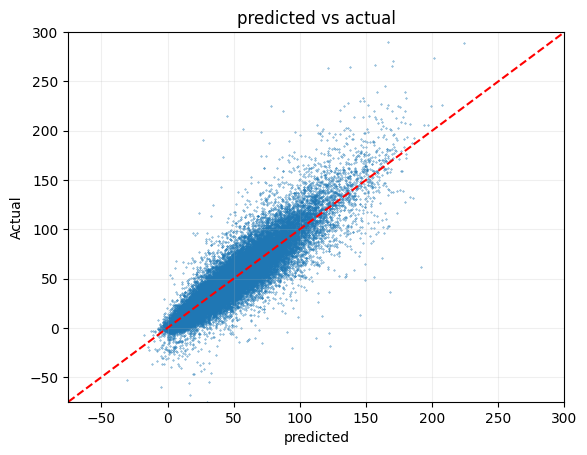


                 Mean Square Error is : 235.28227148145297
                 Mean Absolute Error is : 10.414993471618745
                 R2 score is : 0.7568081735487638
                 Root Mean Square error is: 15.338913634330593
                 Mean percentage error is: 0.3996065374247724


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']
x_train,x_test,y_train,y_test,n_atoms_train,n_atoms_test=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)
hgr_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=80,
    l2_regularization=0.05,
    random_state=10
)

hgr_model.fit(x_train,y_train)
predicted=hgr_model.predict(x_test)


Metrics(predicted,y_test,'hgr Regressor')

# Hist Gradient Boosting with GridSearch

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

x,y=joblib.load("train_data_pca1400.joblib")
original_set = joblib.load("coloumb_pca_pipeline1400.joblib")
n_atoms=original_set['n_atoms']

x_train,x_test,y_train,y_test,n_atoms_train,n_atoms_test=train_test_split(x,y,n_atoms,test_size=0.2,random_state=10)

paramgrid={
    "loss":["squared_error"],
    "learning_rate":[0.1,0.2,0.3,0.05],
    "max_iter":[300,400,800],
    "max_leaf_nodes":[50,30,100],
    "l2_regularization":[0.01,0.05,0.2]
}
hgr=HistGradientBoostingRegressor(random_state=10)

gridsearch= GridSearchCV(
    estimator=hgr,
    param_grid=paramgrid,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    cv=2,
    verbose=3
)

gridsearch.fit(x_train,y_train)

print('Best Parameters:', gridsearch.best_params_)
print('')
print(f'The best Mean Absolute Error: {(gridsearch.best_score_)*-1}')

ypred=gridsearch.best_estimator_.predict(x_test)

mae=mean_absolute_error(y_test,ypred)
mse=mean_squared_error(y_test,ypred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,ypred)

print('')
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2: {r2}')

Fitting 2 folds for each of 108 candidates, totalling 216 fits
Best Parameters: {'l2_regularization': 0.05, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_iter': 800, 'max_leaf_nodes': 100}

The best Mean Absolute Error: 10.785285681052333

MAE: 10.414993471618745
MSE: 235.28227148145297
RMSE: 15.338913634330593
R2: 0.8129312554610998


# Running Model Pipeline On New Data

In [ ]:
class coloumb_test:
    def __init__(self,max_atoms=121):
        self.max_atoms=max_atoms
        model=joblib.load("mlp1024_512_256_128_64_64_28_64_16")
        self.model=model

    def predict(self,jsonpath):
        import joblib
        self.jsonpath=jsonpath
        data=[]
        for path in jsonpath:
            with open(path,'r') as f:
                datas =json.load(f)
                data.append(datas)            
        all_molecules= []
        # Replicates the loop used to extract atom types and xyz coordinates from the JSON objects
        for dataset in data:
            for molecules in dataset:
                row_data=  {}
                for i in range(self.max_atoms):
                    if i<len(molecules['atoms']):
                        atom =molecules['atoms'][i]
                        row_data[f'atom_{i}_type']= atom['type']
                        row_data[f'atom_{i}_x']= atom['xyz'][0]
                        row_data[f'atom_{i}_y']= atom['xyz'][1]
                        row_data[f'atom_{i}_z']= atom['xyz'][2]
                    else:
                        # Maintains the same padding logic for smaller molecules
                        row_data[f'atom_{i}_type']= None
                        row_data[f'atom_{i}_x']= None
                        row_data[f'atom_{i}_y']= None
                        row_data[f'atom_{i}_z']= None
                    
                all_molecules.append(row_data)

        df=pd.DataFrame(all_molecules)
    
        # The same atomic number mapping used in the earlier cell
        zmap = {
            'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10,
            'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15, 'S': 16, 'Cl': 17, 'Ar': 18,
            'K': 19, 'Ca': 20, 'Sc': 21, 'Ti': 22, 'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26,
            'Co': 27, 'Ni': 28, 'Cu': 29, 'Zn': 30, 'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34,
            'Br': 35, 'Kr': 36, 'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41, 'Mo': 42,
            'Tc': 43, 'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50,
            'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54,
            'Cs': 55, 'Ba': 56, 'La': 57, 'Ce': 58, 'Pr': 59, 'Nd': 60,
            'Pm': 61, 'Sm': 62, 'Eu': 63, 'Gd': 64, 'Tb': 65, 'Dy': 66,
            'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71,
            'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77,
            'Pt': 78, 'Au': 79, 'Hg': 80, 'Tl': 81, 'Pb': 82, 'Bi': 83,
            'Po': 84, 'At': 85, 'Rn': 86,
            'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90, 'Pa': 91, 'U': 92,
            'Np': 93, 'Pu': 94, 'Am': 95, 'Cm': 96, 'Bk': 97, 'Cf': 98,
            'Es': 99, 'Fm': 100
        }

        # Processes atom types into numerical Z-values as done previously
        typecols=[col for col in df.columns if col.endswith('_type')]
        df[typecols]=df[typecols].replace(zmap)
        df[typecols]=df[typecols].fillna(0)
        
        # Identifies and isolates coordinate indices for 3D reshaping
        indices=[i for start in range(1,self.max_atoms*4,4) for i in range(start,start+3)]
        print(df.shape)
        dfnew=df.iloc[:,indices]
        print(dfnew.shape)

        d3coords=dfnew.to_numpy(dtype=np.float32)
        d3coords=d3coords.reshape(-1,self.max_atoms,3)

        # Uses the same einsum operations for the Gram matrix and distance calculations
        grammatrix= np.einsum('ijk,ilk->ijl',d3coords,d3coords)
        norms=np.einsum('ijj->ij',grammatrix)
        dist_sq=norms[:,:,None].astype(np.float32) +norms[:,None,:].astype(np.float32) -2*grammatrix.astype(np.float32)

        dist_sq= np.sqrt(np.maximum(dist_sq,0))
        
        # Extracts Z-values matrix for the Coulomb calculation numerator
        indices=[i for i in range(0,((self.max_atoms*4)-1),4)]
        zvalsmatrix=df.iloc[:,indices]
        zvalsmatrix=zvalsmatrix.to_numpy(dtype=np.float32)

        # Computes Zi * Zj for the matrix elements
        all_zvals=np.einsum('ij,ik->ijk',zvalsmatrix,zvalsmatrix)

        # Constructs the Coulomb Matrix elements (Zi * Zj / Rij)
        columbmatrix= all_zvals/dist_sq

        # Replicates the diagonal calculation: 0.5 * Zi^2.4
        diags=0.5*(zvalsmatrix**2.4)

        # Manually updates diagonals for every molecule in the set
        val= np.arange(self.max_atoms)
        for k in range(df.shape[0]):
            for i in range(self.max_atoms):
                columbmatrix[k,i,i]=diags[k,i]
        
        # Flattens the matrix and separates the target 'energy' (y)
        x=columbmatrix.reshape(df.shape[0],-1)

        x=pd.DataFrame(x.astype(np.float32))
        x=x.fillna(0)

        pipeline= joblib.load("coloumb_pca_pipeline1400.joblib")        
        pca=pipeline['pca']
        sc=pipeline['scaler']

        # Fit and transform the data 
        x_scaled=sc.transform(x).astype(np.float32)
        del x

        x_test=pca.transform(x_scaled)

        # # Transform the scaled features into the reduced PCA space
        # x_pca=pca.fit_transform(x_scaled).astype(np.float32)
       
        y=self.model.predict(x_test)

        
        return y
  
        


# How to use the testing function 
### y_trial will contain the predicted energy values

In [ ]:
Checking_set=coloumb_test()
y_trial=Checking_set.predict(jsonpath = [r"Dataset/pubChem_p_00000001_00025000.json"])

(18205, 484)
(18205, 363)


# Random Search with Wandb (REDACTED)

In [ ]:
# # Define the core training function that W&B will call for each iteration of the sweep
# x,y=joblib.load("train_data_pca.joblib")
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

# def train():
    
#         # Initialize a new W&B run
#     with wandb.init():
#         # Access the hyperparameters generated by the sweep for this specific run
#         c = wandb.config
        
#         # Instantiate the regressor based on the 'model_type' chosen by the sweep agent
#         # if c.model_type == 'mlp':
#         #     model = MLPRegressor(hidden_layer_sizes=c.hidden_layer_sizes, activation=c.activation, 
#         #                         solver=c.solver, alpha=c.mlp_alpha, learning_rate_init=c.learning_rate_init,max_iter=c.max_iter)
#         # elif c.model_type == 'knn':
#         #     model = KNeighborsRegressor(n_neighbors=c.n_neighbors, weights=c.weights, metric=c.knn_metric,n_jobs=-1)
#         # elif c.model_type == 'dt':
#         #     model = DecisionTreeRegressor(max_depth=c.dt_max_depth, min_samples_split=c.dt_min_samples_split, 
#         #                                 min_samples_leaf=c.dt_min_samples_leaf, max_features=c.dt_max_features)
#         if c.model_type == 'rf':
#             model = RandomForestRegressor(n_estimators=c.rf_n_estimators, max_depth=c.rf_max_depth) 
#         #                                 min_samples_split=c.rf_min_samples_split, max_features=c.rf_max_features,n_jobs=-1)
#         # elif c.model_type == 'gb': 
#         #     model = GradientBoostingRegressor(n_estimators=c.gb_n_estimators, learning_rate=c.gb_learning_rate, 
#         #                                     max_depth=c.gb_max_depth, subsample=c.gb_subsample, loss=c.gb_loss)
#         # elif c.model_type== 'lasso':
#         #     model= Lasso(alpha=c.lasso_alpha)
#         # elif c.model_type== 'ridge':
#         #     model=Ridge(alpha=c.rid_alpha,solver=c.rid_solver)
        

#         # Evaluate model performance using 5-fold cross-validation on the training data
#         # cv_scores_mse = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
#         # cv_scores_r2 = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
        
#         # # Calculate aggregate CV metrics: Mean RMSE, Mean R2, and Standard Deviation of RMSE
#         # cv_rmse = np.sqrt(-cv_scores_mse.mean())
#         # cv_r2 = cv_scores_r2.mean()
#         # cv_rmse_std=np.sqrt(-cv_scores_mse).std()

#         # Train the model on the full training set and generate predictions on the test set
#         model.fit(x_train, y_train)
#         y_pred = model.predict(x_test)
        

#         # Compute standard regression error metrics for evaluation (not cross-validated)
#         mse = mean_squared_error(y_test, y_pred)
#         rmse = np.sqrt(mse)
#         mae = mean_absolute_error(y_test, y_pred)
#         r2 = r2_score(y_test, y_pred)

#         # For tree-based models, extract and log the top 20 most important features (Principal Components)
#         if c.model_type in ['rf','dt']:
#             importance=model.feature_importances_
#             top_n=20 # how many features to log
#             indices = np.argsort(importance)[::-1] # Indices of the most important features (reversed so descending order)
#             indices=indices[0:top_n] 
#             importances=importance[indices] # Specifically the importances which lie at the top 20 indices

#             # Sort indices numerically to maintain PC order in the bar plot
#             s=np.argsort(indices)
#             indices=np.array(sorted(indices))
#             indices+=1 # Adjust for 1-based indexing of Principal Components
#             importances=[importances[i] for i in s]

#             indicesstr= [f'PC{i+1}' for i in indices] # list comprehension to convert numeric to categorical (or else y axis get messy)

#             plt.figure(figsize=(10,10))

#             plt.barh(indicesstr,importances)
#             plt.xlabel('Importance')
#             plt.ylabel('Principal Component')
#             plt.title(f'Feature Importance rmse: {rmse:.2f}')
#             # Log the plot as an image to the W&B dashboard
#             wandb.log({"feature_importance": wandb.Image(plt)})
#             plt.close()

#         # For linear models (Ridge/Lasso), extract and log the top 20 absolute coefficient weights
#         if c.model_type in ['ridge', 'lasso']:
#             coef = np.abs(model.coef_) #list of all 448 coefficients values in order
#             top_n=20
#             indices = np.argsort(coef)[::-1]
#             indices=indices[0:top_n]                # Follows the exact same logic now as feature importances in previous
#             importances=coef[indices]

#             s=np.argsort(indices)
#             indices=np.array(sorted(indices))
#             indices+=1
#             importances=[importances[i] for i in s]

#             indicesstr= [f'PC{i}' for i in indices]

#             plt.figure(figsize=(10,10))

#             plt.barh(indicesstr,importances)
#             plt.xlabel('Feature Weight')
#             plt.ylabel('Principal Component')
#             plt.title(f'Feature Weight rmse: {rmse:.2f}')
#             wandb.log({"feature_weight": wandb.Image(plt)})
#             plt.close()

#         # Log the MLP training loss curve if the solver is not 'lbfgs' (lbfgs was removed because on 18000 samples it was very slow and frying my laptop)
#         if c.model_type=='mlp' and c.solver != 'lbfgs':
#             plt.figure()
#             plt.plot(model.loss_curve_) # grab the loss array and plot it
#             plt.xlabel('Epochs')
#             plt.ylabel('Loss')
#             plt.title(f'Loss Curve: Final value {model.loss_curve_[-1]:.3f}') # Mention the final loss in the title
#             plt.grid(alpha=0.3)
#             wandb.log({'Loss Curve':wandb.Image(plt)}) # log the image
#             plt.close()

#         # Generate and log a scatter plot of Actual vs. Predicted energy values
#         plt.figure()
#         plt.scatter(y_test,y_pred,s=0.1) # marker size small since 18000+ samples
#         plt.xlabel('Actual Values')
#         plt.ylabel('Predicted Values')
#         plt.title(f'Actual vs Predicted for {c.model_type} with rmse {rmse:.2f}') 
#         plt.xlim(-100,300)
#         plt.ylim(-100,300)  
#         plt.grid(alpha=0.3)
#         # Add a red dashed line representing perfect prediction (y=x)
#         plt.axline((0,0),slope=1,linestyle='--',color='red')  # 'perfect' line plot
#         wandb.log({'Actual_vs_Predicted':wandb.Image(plt)})
#         plt.close()
        
        
#         # Log all calculated numeric metrics to the W&B run
#         wandb.log({"mse": mse, "rmse": rmse, "mae": mae, "r2": r2,'model_type_tag':c.model_type})
  


# # Define the dictionary of model-specific hyperparameter search spaces
# model_params={

#         # 'dt':{ 'dt_max_depth': {'values': [None, 5, 10, 15, 50]},
#         # 'dt_min_samples_split': {'values': [2, 5, 20]},
#         # 'dt_min_samples_leaf': {'values': [1, 2, 8]},
#         # 'dt_max_features': {'values': [None, 'sqrt', 'log2']}},

#         # 'knn':{'n_neighbors': {'values': [2, 3]},
#         # 'weights': {'values': ['uniform', 'distance']},
#         # 'knn_metric': {'values': ['euclidean']}},

#         'rf':{ 'rf_n_estimators': {'values': [50, 100, 200, 300]},
#         'rf_max_depth': {'values': [10, 20, 30, 40]},
#         'rf_min_samples_split': {'values': [2, 5, 10]},
#         'rf_max_features': {'values': ['sqrt', 'log2']}}

#         # 'ridge': {'rid_alpha': {'values': [0.01, 0.1, 1]},'rid_solver':{'values':['auto']}},
#         # 'lasso': {'lasso_alpha': {'values': [i/5 for i in range(20)]}},

#         # 'mlp':{'hidden_layer_sizes': {'values': [(100,), (200, 100), (128, 64, 32), (50, 50, 25)]},
#         # 'activation': {'values': ['relu', 'tanh', 'logistic']},
#         # 'solver': {'values': ['adam', 'sgd']},
#         # 'mlp_alpha': {'values': [0.0005, 0.001, 0.01, 0.1]},
#         # 'learning_rate_init': {'values': [0.0005, 0.001, 0.01]},
#         # 'max_iter':{'values':[3000]}}
        
#         }

# # Loop through each model type to create a separate sweep and launch a W&B agent
# for model_type,params in model_params.items(): # key,value in model_params.items()
#         sweep_config={
#             'method':'random', # Use random search to explore the parameter space
#             'metric':{'name':'rmse','goal':'minimize'},
#             'parameters':{
#                 'model_type':{'value':model_type},
#                 **params # unpacks the specific parameters for the model_type that is currently selected (basically adds whats inside the dictionary to this new dictionary)
#             }
#         }
#         # Initialize the sweep on the W&B server
#         sweep_id=wandb.sweep(sweep_config,project='Random Forest Molecular')
#         # Execute the sweep with the train function, limiting each model type to 10 iterations
#         wandb.agent(sweep_id,function=train,count=10)